# Neural Networks

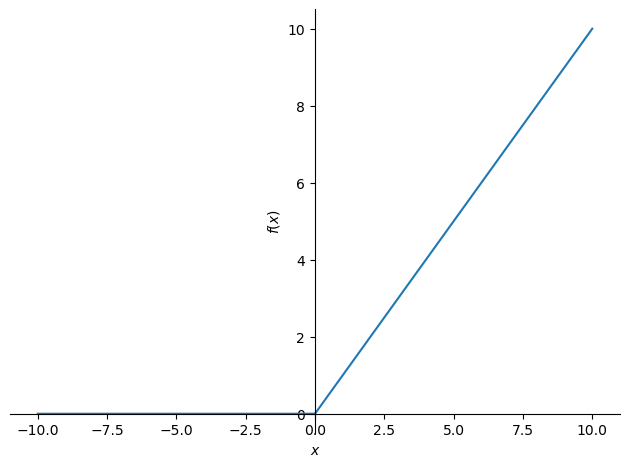

In [1]:
from sympy import *

x = symbols('x')
relu = Max(0,x)
plot(relu)

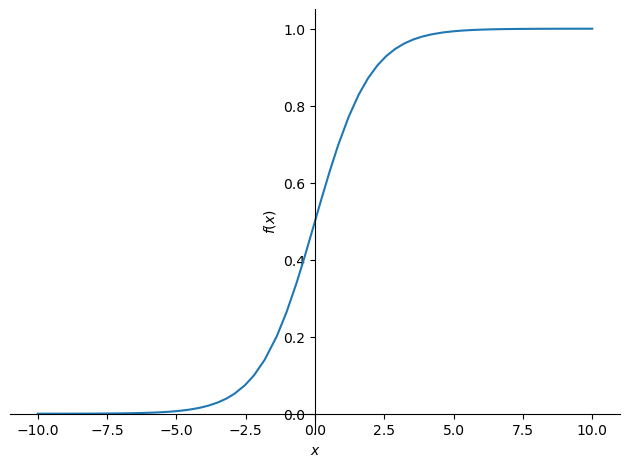

In [2]:
x = symbols('x')
logistic = 1 / (1 + exp(-x))
plot(logistic)

### Fordward Propagation

In [17]:
#Simple Forward Propagation with random weight and bias values
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split

all_data = pd.read_csv("https://tinyurl.com/y2qmhfsr")

#Extract the input colum, scale down by 255
all_inputs = (all_data.iloc[:, 0:3].values / 255.0)
all_outputs = all_data.iloc[:, -1].values

#Split train and test data sets
X_train, X_test, Y_train, Y_test = train_test_split(all_inputs, all_outputs, test_size=1/3)

n = X_train.shape[0] #Number of training records

#Build Neural Network with weights and biases with random initialization
w_hidden = np.random.rand(3,3)
w_output = np.random.rand(1,3)

b_hidden = np.random.rand(3,1)
b_output = np.random.rand(1,1)

#Activation functions
relu = lambda x: np.maximum(x,0)
logistic = lambda x: 1 / (1 + np.exp(-x))

#Runs inputs through the neural network to get predicted outputs
def forward_prop(X):
    Z1 = w_hidden @ X +b_hidden
    A1 = relu(Z1)
    Z2 = w_output @ A1 + b_output
    A2 = logistic(Z2)
    return Z1, A1, Z2, A2

#Calculate Accuracy
test_predictions = forward_prop(X_test.transpose())[3] #Grab only output layes, A2
test_comparisons = np.equal((test_predictions >= 0.5).flatten().astype(int), Y_test)
accuracy = sum(test_comparisons.astype(int) / X_test.shape[0])

print(f'Accuracy: {accuracy}')

Accuracy: 0.6258351893095758


In [11]:
X_train.shape

(896, 3)

In [12]:
X_train

array([[0.28235294, 0.81960784, 0.8       ],
       [0.        , 0.80784314, 0.81960784],
       [0.        , 0.        , 0.        ],
       ...,
       [0.47058824, 0.47058824, 0.47058824],
       [0.90196078, 0.90196078, 0.70196078],
       [0.        , 0.        , 0.54509804]])

### Backpropagation

In [18]:
# dC/dW2 = dZ2/dW2 . dA2/dZ2 . dC/dA2

In [20]:
# dC/dA2
from sympy import *
A2, Y = symbols ('A2 Y')
C = (A2 - Y)**2

dC_dA2 = diff(C, A2)
print(dC_dA2)

2*A2 - 2*Y


In [21]:
# dA2/dZ2
Z2 = symbols('Z2')
logistic = lambda x: 1 / (1 + exp(-x))

A2 = logistic(Z2)
dA2_dZ2 = diff(A2, Z2)
print(dA2_dZ2)

exp(-Z2)/(1 + exp(-Z2))**2


In [22]:
# dZ2/dW2
A1, W2, B2 = symbols('A1 W2 B2')

Z2 = A1*W2 +B2
dZ2_dW2 = diff (Z2, W2)
print(dZ2_dW2)

A1


In [14]:
#Calculating all the partial derivatives we will need for a neural network
from sympy import *

W1, W2, B1, B2, A1, A2, Z1, Z2, X, Y = symbols ('W1 W2 B1 B2 A1 A2 Z1 Z2 X Y')

#Calculate derivative of cost function with respect to A2
C = (A2 -Y)**2
dC_dA2 = diff(C, A2)
print(f'{dC_dA2 = }')

#Calculate derivative of A2 with respect to Z2
logistic = lambda x: 1 / (1 + exp(-x))

_A2 = logistic(Z2)
dA2_dZ2 = diff(_A2, Z2)
print(f'{dA2_dZ2 = }')

# Calculate the derivative of Z2 with respect to A1
_Z2 = A1*W2 + B2
dZ2_dA1 = diff (_Z2, A1)
print(f'{dZ2_dA1 = }')

#Calculate the derivative of Z2 with respect to W2
dZ2_dW2 = diff (_Z2, W2)
print(f'{dZ2_dW2 = }')

#Calculate derivative of Z2 with respect to B2
dZ2_dB2 = diff (_Z2, B2)
print(f'{dZ2_dB2 = }')

#Calculate the derivative of A1 with respect to Z1
relu = lambda x: Max(x, 0)
_A1 = relu(Z1)
d_relu = lambda x: x > 0 #Slope is 1 if positive, 0 if negative
dA1_dZ1 = d_relu(Z1)
print(f'{dA1_dZ1 = }')

#Calculate derivative of Z1 with respect to W1
_Z1 = X*W1 + B1
dZ1_dW1 = diff(_Z1, W1)
print(f'{dZ1_dW1 = }')

#Calculate derivative of Z1 with resoect to B1
dZ1_dB1 = diff(_Z1, B1)
print(f'{dZ1_dB1 = }')

dC_dA2 = 2*A2 - 2*Y
dA2_dZ2 = exp(-Z2)/(1 + exp(-Z2))**2
dZ2_dA1 = W2
dZ2_dW2 = A1
dZ2_dB2 = 1
dA1_dZ1 = Z1 > 0
dZ1_dW1 = X
dZ1_dB1 = 1


In [24]:
#Implementing a neural network using stochastic gradient descent

import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split

all_data = pd.read_csv("https://tinyurl.com/y2qmhfsr")

#Lerning rate controls how slowly we approach a solution. Make it too small, it will take too long to run
#Make it too big, it will likely overshoot and miss the slution
L = 0.05

#Extract the input colum, scale down by 255
all_inputs = (all_data.iloc[:, 0:3].values / 255.0)
all_outputs = all_data.iloc[:, -1].values

#Split train and test data sets
X_train, X_test, Y_train, Y_test = train_test_split(all_inputs, all_outputs, test_size=1/3)

n = X_train.shape[0] 

#Build Neural Network with weights and biases
w_hidden = np.random.rand(3,3)
w_output = np.random.rand(1,3)

b_hidden = np.random.rand(3,1)
b_output = np.random.rand(1,1)

#Activation functions
relu = lambda x: np.maximum(x,0)
logistic = lambda x: 1 / (1 + np.exp(-x))

#Runs inputs through the neural network to get predicted outputs
def forward_prop(X):
    Z1 = w_hidden @ X +b_hidden
    A1 = relu(Z1)
    Z2 = w_output @ A1 + b_output
    A2 = logistic(Z2)
    return Z1, A1, Z2, A2

#Derivatives of activation functions
d_relu = lambda x: x > 0 #Slope is 1 if positive, 0 if negative
d_logistic = lambda x: np.exp(-x) / (1 + np.exp(-x)) ** 2

#Return slopes for weights and biases using chain rule
def backward_prop(Z1, A1, Z2, A2, X, Y):
    dC_dA2 = 2*A2 - 2*Y
    dA2_dZ2 = d_logistic(Z2)
    dZ2_dA1 = w_output
    dZ2_dW2 = A1
    dZ2_dB2 = 1
    dA1_dZ1 = d_relu(Z1)
    dZ1_dW1 = X
    dZ1_dB1 = 1

    dC_dW2 = dC_dA2 @ dA2_dZ2 @ dZ2_dW2.T

    dC_dB2 = dC_dA2 @ dA2_dZ2 * dZ2_dB2
    
    dC_dA1 = dC_dA2 @ dA2_dZ2 @ dZ2_dA1

    dC_dW1 = dC_dA1 @ dA1_dZ1 @ dZ1_dW1.T

    dC_dB1 = dC_dA1 @ dA1_dZ1 * dZ1_dB1

    return dC_dW1, dC_dB1, dC_dW2, dC_dB2

#Execute Gradient Descent
for i in range(100_000):
    #randomly select one of the training data
    idx = np.random.choice(n, 1, replace=False)
    X_sample = X_train[idx].transpose()
    Y_sample = Y_train[idx]

    #run randomly selected training data through NW
    Z1, A1, Z2, A2 = forward_prop(X_sample)

    #distribute error through backpropagation and return slopes for weights and biases
    dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

    #update weights and biases
    w_hidden -= L * dW1
    b_hidden -= L * dB1
    w_output -= L * dW2
    b_output -= L * dB2
    
#Calculate Accuracy
test_predictions = forward_prop(X_test.transpose())[3] #Grab only A2
test_comparisons = np.equal((test_predictions >= 0.5).flatten().astype(int), Y_test)
accuracy = sum(test_comparisons.astype(int) / X_test.shape[0])
print(f'Accuracy: {accuracy}')

Accuracy: 0.973273942093534


In [28]:
#Interactive and test with new colors
def predict_probability(r, g, b):
    X = np.array([[r, g, b]]).transpose() / 255
    Z1, A1, Z2, A2 = forward_prop(X)
    return A2

def predict_front_shade(r, g, b):
    output_values = predict_probability(r, g, b)
    if output_values > 0.5:
        return "DARK"
    else:
        return "LIGHT"

a = 0
while a == 0:
    col_input = input("Predict light or dark font. Input values R,G,B: ")
    (r,g,b) = col_input.split(",")
    print(predict_front_shade(int(r), int(g), int(b)))

    b = input("If you want to predict other value press 'y', if you want to finish the program just type other letter: ")

    if str(b) == 'y':
        a = 0
    else:
        a = 1
        print("Goodbye")

Predict light or dark font. Input values R,G,B:  200,150,1


DARK


If you want to predict other value press 'y', if you want to finish the program just type other letter:  s


Goodbye


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

df = pd.read_csv('https://bit.ly/3GsNzGt', delimiter=",")

#Extract input variables
#Linear Scaling
X = (df.values[:, :-1] / 255.0)
#Extract output column
Y = df.values[:, -1]

#Separate training and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3)

nn = MLPClassifier(hidden_layer_sizes=(3,),
                  activation='relu',
                  solver='sgd',
                  max_iter=100_000,
                  learning_rate_init=.05)

nn.fit(X_train, Y_train)

#print weights and biases
print(nn.coefs_)
print(nn.intercepts_)

print("Training set score: %f" % nn.score(X_train, Y_train))
print("Test set score: %f" % nn.score(X_test, Y_test))

[array([[-0.47072972, -3.02807043, -0.95506443],
       [-0.3209126 , -6.10876534, -0.21076708],
       [-0.39459622, -1.11487169,  0.22439115]]), array([[ 0.94574364],
       [-8.92379297],
       [ 0.04021884]])]
[array([-0.37342014,  5.76601387, -0.22223015]), array([5.66628919])]
Training set score: 0.997768
Test set score: 1.000000


## Exercise

In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

df = pd.read_csv('https://tinyurl.com/y6r7qjrp', delimiter=",")

In [46]:
df.head()

,SEX,AGE,PROMOTIONS,YEARS_EMPLOYED,DID_QUIT
0,0,25,2,3,0
1,0,30,2,3,0
2,0,26,2,3,0
3,0,25,1,2,0
4,0,28,1,2,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   SEX             54 non-null     int64
 1   AGE             54 non-null     int64
 2   PROMOTIONS      54 non-null     int64
 3   YEARS_EMPLOYED  54 non-null     int64
 4   DID_QUIT        54 non-null     int64
dtypes: int64(5)
memory usage: 2.2 KB


In [57]:
X = df.values[:,:-1]
Y = df.values[:,-1]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=1/3)

NM_model = MLPClassifier(hidden_layer_sizes=(3,),activation='relu',solver='adam',max_iter=100_000,learning_rate_init=0.05)

NM_model.fit(X_train,Y_train)

MLPClassifier(hidden_layer_sizes=(3,), learning_rate_init=0.05, max_iter=100000)

In [58]:
print("Training set score: %f" % NM_model.score(X_train, Y_train))
print("Test set score: %f" % NM_model.score(X_test, Y_test))

Training set score: 0.833333
Test set score: 0.638889


In [59]:
matrix=confusion_matrix(y_true=Y_test,y_pred=NM_model.predict(X_test))
print(matrix)

[[14  6]
 [ 7  9]]
